In [1]:
!pip -q install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [2]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

from torch.optim import AdamW

from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TEACHER_MODEL_NAME = "google-bert/bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16

print("Device:", DEVICE)

Device: cuda


In [4]:
DATASET_NAME = "sst2"     
# Opciones:
# "sst2"
# "ag_news"
# "yelp"

In [5]:
def get_dataset_info(dataset_name):
    if dataset_name == "sst2":
        return {
            "hf_name": "glue",
            "hf_config": "sst2",
            "text_column": "sentence",
            "label_column": "label",
            "num_labels": 2,
            "train_split": "train",
            "validation_split": "validation"
        }

    elif dataset_name == "ag_news":
        return {
            "hf_name": "ag_news",
            "hf_config": None,
            "text_column": "text",
            "label_column": "label",
            "num_labels": 4,
            "train_split": "train",
            "validation_split": "test"
        }

    elif dataset_name == "yelp":
        return {
            "hf_name": "yelp_review_full",
            "hf_config": None,
            "text_column": "text",
            "label_column": "label",
            "num_labels": 5,
            "train_split": "train",
            "validation_split": "test"
        }

    else:
        raise ValueError("Dataset no soportado.")

# Data Base

In [6]:
info = get_dataset_info(DATASET_NAME)

if info["hf_config"] is None:
    raw_dataset = load_dataset(info["hf_name"])
else:
    raw_dataset = load_dataset(info["hf_name"], info["hf_config"])

num_labels = info["num_labels"]

print(raw_dataset)
print("Número de clases:", num_labels)

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})
Número de clases: 2


In [7]:
train_size = min(5000, len(raw_dataset[info["train_split"]]))
valid_size = min(1000, len(raw_dataset[info["validation_split"]]))

train_dataset = raw_dataset[info["train_split"]].shuffle(seed=42).select(range(train_size))
valid_dataset = raw_dataset[info["validation_split"]].shuffle(seed=42).select(range(valid_size))

print(train_dataset)
print(valid_dataset)

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 5000
})
Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 872
})


# Tokenizer

In [8]:
tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
def tokenize_function(batch):
    return tokenizer(
        batch[info["text_column"]],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [10]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_valid = valid_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.rename_column(info["label_column"], "labels")
tokenized_valid = tokenized_valid.rename_column(info["label_column"], "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]

tokenized_train.set_format(type="torch", columns=columns_to_keep)
tokenized_valid.set_format(type="torch", columns=columns_to_keep)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [11]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_valid = valid_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.rename_column(info["label_column"], "labels")
tokenized_valid = tokenized_valid.rename_column(info["label_column"], "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]

tokenized_train.set_format(type="torch", columns=columns_to_keep)
tokenized_valid.set_format(type="torch", columns=columns_to_keep)

# Data Loader

In [12]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    tokenized_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

valid_loader = DataLoader(
    tokenized_valid,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

# Bert Pre training

In [13]:
teacher = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_MODEL_NAME,
    num_labels=num_labels
)

teacher.to(DEVICE)
teacher.eval()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# Distill BERT

In [14]:
class DistillBERT(nn.Module):
    def __init__(
        self,
        vocab_size=30522,
        max_len=512,
        dmodel=768,
        ffd=3072,
        n_heads=12,
        n_layers=6,
        num_labels=2,
        dropout=0.1,
        pad_token_id=0
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            dmodel,
            padding_idx=pad_token_id
        )

        self.position_embedding = nn.Embedding(
            max_len,
            dmodel
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dmodel,
            nhead=n_heads,
            dim_feedforward=ffd,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(dmodel, num_labels)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.shape

        position_ids = torch.arange(
            seq_len,
            device=input_ids.device
        ).unsqueeze(0).expand(batch_size, seq_len)

        token_embeds = self.token_embedding(input_ids)
        position_embeds = self.position_embedding(position_ids)

        hidden_states = token_embeds + position_embeds

        if attention_mask is not None:
            padding_mask = attention_mask == 0
        else:
            padding_mask = None

        hidden_states = self.encoder(
            hidden_states,
            src_key_padding_mask=padding_mask
        )

        cls_output = hidden_states[:, 0, :]
        cls_output = self.dropout(cls_output)

        logits = self.classifier(cls_output)

        return logits

In [15]:
student = DistillBERT(
    vocab_size=tokenizer.vocab_size,
    max_len=512,
    dmodel=768,
    ffd=3072,
    n_heads=12,
    n_layers=6,
    num_labels=num_labels,
    dropout=0.1,
    pad_token_id=tokenizer.pad_token_id
)

student.to(DEVICE)

/tmp/ipykernel_57/1699534801.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


DistillBERT(
  (token_embedding): Embedding(30522, 768, padding_idx=0)
  (position_embedding): Embedding(512, 768)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=3072, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=3072, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=768, out_features=2, bias=True)
)

# Copy Embeddings

In [16]:
def copy_embeddings_from_teacher(teacher, student):
    with torch.no_grad():
        student.token_embedding.weight.copy_(
            teacher.bert.embeddings.word_embeddings.weight
        )

        student.position_embedding.weight.copy_(
            teacher.bert.embeddings.position_embeddings.weight
        )

copy_embeddings_from_teacher(teacher, student)

# Loss Knowledge Destillation

In [17]:
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.5, temperature=2.0):
        super().__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce_loss = nn.CrossEntropyLoss()
        self.kl_loss = nn.KLDivLoss(reduction="batchmean")

    def forward(self, student_logits, teacher_logits, labels):
        hard_loss = self.ce_loss(student_logits, labels)

        soft_student = F.log_softmax(
            student_logits / self.temperature,
            dim=-1
        )

        soft_teacher = F.softmax(
            teacher_logits / self.temperature,
            dim=-1
        )

        soft_loss = self.kl_loss(
            soft_student,
            soft_teacher
        ) * (self.temperature ** 2)

        total_loss = (
            self.alpha * hard_loss
            + (1 - self.alpha) * soft_loss
        )

        return total_loss

In [18]:
distillation_loss = DistillationLoss(
    alpha=0.5,
    temperature=2.0
)

# Testing

In [19]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)
labels = batch["labels"].to(DEVICE)

with torch.no_grad():
    teacher_outputs = teacher(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

student_logits = student(
    input_ids=input_ids,
    attention_mask=attention_mask
)

teacher_logits = teacher_outputs.logits

loss = distillation_loss(
    student_logits=student_logits,
    teacher_logits=teacher_logits,
    labels=labels
)

print("Teacher logits:", teacher_logits.shape)
print("Student logits:", student_logits.shape)
print("Loss:", loss.item())

Teacher logits: torch.Size([16, 2])
Student logits: torch.Size([16, 2])
Loss: 0.3785412013530731


# Métricas

In [20]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Evaluacion

In [21]:
def evaluate_model(model, dataloader, device, is_teacher=True):
    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0
    ce_loss = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if is_teacher:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                logits = outputs.logits
                loss = outputs.loss

            else:
                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = ce_loss(logits, labels)

            preds = torch.argmax(logits, dim=-1)

            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = total_loss / len(dataloader)

    return metrics

In [22]:
teacher_metrics = evaluate_model(
    teacher,
    valid_loader,
    DEVICE,
    is_teacher=True
)

student_metrics = evaluate_model(
    student,
    valid_loader,
    DEVICE,
    is_teacher=False
)

print("Teacher:", teacher_metrics)
print("Student:", student_metrics)

Teacher: {'accuracy': 0.4908256880733945, 'precision': 0.24090985607272117, 'recall': 0.4908256880733945, 'f1': 0.32318983768525056, 'loss': 0.7112127737565475}
Student: {'accuracy': 0.5034403669724771, 'precision': 0.5068174101539653, 'recall': 0.5034403669724771, 'f1': 0.49309214654842, 'loss': 0.7891375541687011}


# Train

In [23]:
def one_epoch_train(
    teacher,
    student,
    criterion,
    optimizer,
    dataloader,
    device,
    max_grad_norm=1.0
):
    teacher.eval()
    student.train()

    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device, dtype=torch.long)
        attention_mask = batch["attention_mask"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device, dtype=torch.long)

        optimizer.zero_grad()

        with torch.no_grad():
            teacher_outputs = teacher(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            teacher_logits = teacher_outputs.logits

        student_logits = student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(
            student_logits,
            teacher_logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            student.parameters(),
            max_norm=max_grad_norm
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    return avg_loss

In [24]:
def train(
    teacher,
    student,
    criterion,
    optimizer,
    datatrain,
    dataeval,
    epochs,
    device,
    max_grad_norm=1.0
):
    history_loss = []
    history_eval = []

    teacher.to(device)
    student.to(device)

    for epoch in range(epochs):
        train_loss = one_epoch_train(
            teacher=teacher,
            student=student,
            criterion=criterion,
            optimizer=optimizer,
            dataloader=datatrain,
            device=device,
            max_grad_norm=max_grad_norm
        )

        history_loss.append(train_loss)

        student_eval = evaluate_model(
            student,
            dataeval,
            device,
            is_teacher=False
        )

        history_eval.append(student_eval)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {student_eval['loss']:.4f} | "
            f"Acc: {student_eval['accuracy']:.4f} | "
            f"F1: {student_eval['f1']:.4f}"
        )

    return history_loss, history_eval

In [25]:
from torch.optim import AdamW

optimizer = AdamW(
    student.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

history_loss, history_eval = train(
    teacher=teacher,
    student=student,
    criterion=distillation_loss,
    optimizer=optimizer,
    datatrain=train_loader,
    dataeval=valid_loader,
    epochs=3,
    device=DEVICE
)

Epoch [1/3] | Train Loss: 0.4212 | Val Loss: 0.5843 | Acc: 0.7064 | F1: 0.6934


Epoch [2/3] | Train Loss: 0.3524 | Val Loss: 0.5480 | Acc: 0.7729 | F1: 0.7729


Epoch [3/3] | Train Loss: 0.3236 | Val Loss: 0.5885 | Acc: 0.6640 | F1: 0.6317


# Contar parametros

In [26]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "total_params": total_params,
        "trainable_params": trainable_params
    }

In [27]:
teacher_params = count_parameters(teacher)
student_params = count_parameters(student)

print("Teacher params:", teacher_params)
print("Student params:", student_params)

Teacher params: {'total_params': 109483778, 'trainable_params': 109483778}
Student params: {'total_params': 66362882, 'trainable_params': 66362882}


# Latencia

In [28]:
def measure_latency(model, dataloader, device, is_teacher=True, num_batches=30):
    model.eval()

    times = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            if device == "cuda":
                torch.cuda.synchronize()

            start_time = time.time()

            if is_teacher:
                _ = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
            else:
                _ = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            if device == "cuda":
                torch.cuda.synchronize()

            end_time = time.time()

            times.append(end_time - start_time)

    return {
        "avg_latency_per_batch": np.mean(times),
        "avg_latency_per_sample": np.mean(times) / BATCH_SIZE
    }

In [29]:
teacher_latency = measure_latency(
    teacher,
    valid_loader,
    DEVICE,
    is_teacher=True
)

student_latency = measure_latency(
    student,
    valid_loader,
    DEVICE,
    is_teacher=False
)

print("Teacher latency:", teacher_latency)
print("Student latency:", student_latency)

Teacher latency: {'avg_latency_per_batch': np.float64(0.039452735582987467), 'avg_latency_per_sample': np.float64(0.0024657959739367167)}
Student latency: {'avg_latency_per_batch': np.float64(0.018872634569803873), 'avg_latency_per_sample': np.float64(0.001179539660612742)}


# uso de GPU

In [30]:
def measure_gpu_memory(model, dataloader, device, is_teacher=True):
    if device != "cuda":
        return {"gpu_memory_mb": None}

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    model.eval()

    batch = next(iter(dataloader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    with torch.no_grad():
        if is_teacher:
            _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        else:
            _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

    return {
        "gpu_memory_mb": peak_memory
    }

In [31]:
teacher_memory = measure_gpu_memory(
    teacher,
    valid_loader,
    DEVICE,
    is_teacher=True
)

student_memory = measure_gpu_memory(
    student,
    valid_loader,
    DEVICE,
    is_teacher=False
)

print("Teacher memory:", teacher_memory)
print("Student memory:", student_memory)

Teacher memory: {'gpu_memory_mb': 1657.552734375}
Student memory: {'gpu_memory_mb': 1657.52685546875}


# Resultados

In [32]:
results = pd.DataFrame([
    {
        "model": "BERT Base Teacher",
        "accuracy": teacher_metrics["accuracy"],
        "precision": teacher_metrics["precision"],
        "recall": teacher_metrics["recall"],
        "f1": teacher_metrics["f1"],
        "loss": teacher_metrics["loss"],
        "parameters": teacher_params["total_params"],
        "latency_per_sample": teacher_latency["avg_latency_per_sample"],
        "gpu_memory_mb": teacher_memory["gpu_memory_mb"]
    },
    {
        "model": "Custom DistilBERT Student",
        "accuracy": student_metrics["accuracy"],
        "precision": student_metrics["precision"],
        "recall": student_metrics["recall"],
        "f1": student_metrics["f1"],
        "loss": student_metrics["loss"],
        "parameters": student_params["total_params"],
        "latency_per_sample": student_latency["avg_latency_per_sample"],
        "gpu_memory_mb": student_memory["gpu_memory_mb"]
    }
])

results

,model,accuracy,precision,recall,f1,loss,parameters,latency_per_sample,gpu_memory_mb
0,BERT Base Teacher,0.490826,0.240910,0.490826,0.323190,0.711213,109483778,0.002466,1657.552734
1,Custom DistilBERT Student,0.503440,0.506817,0.503440,0.493092,0.789138,66362882,0.001180,1657.526855


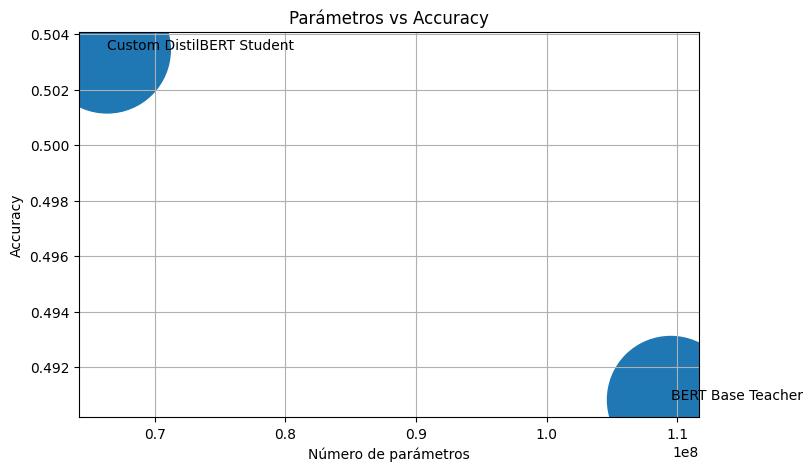

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    results["parameters"],
    results["accuracy"],
    s=results["gpu_memory_mb"].fillna(100) * 5
)

for i, row in results.iterrows():
    plt.text(
        row["parameters"],
        row["accuracy"],
        row["model"]
    )

plt.xlabel("Número de parámetros")
plt.ylabel("Accuracy")
plt.title("Parámetros vs Accuracy")
plt.grid(True)
plt.show()

Falta:

* Fine tuning de cada dataset del teacher
* guardar el teacher pre entrenado
* usar el teacher para entrenar el student
* geenrar el grafico de las burbujas, eficiencia, metricas, gpu, ... (para cada dataset)
* comparar esos resultados